This notebook computes the WIS for the predictions normalized by the total cases in the period:

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt 
from itertools import product
from metrics import compute_metrics 

# Definir a cor das bordas (spines) como cinza
mpl.rcParams['axes.edgecolor'] = 'gray'

# Definir a cor das linhas dos ticks maiores e menores como cinza
mpl.rcParams['xtick.color'] = 'gray'
mpl.rcParams['ytick.color'] = 'gray'
mpl.rcParams['xtick.labelcolor'] = 'black'
mpl.rcParams['ytick.labelcolor'] = 'black'
plt.rcParams['axes.labelsize'] = 16 # Axis labels
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick labels
plt.rcParams['font.size'] = 16  # General font size
FONT = 12


Load the data:

In [2]:
data = pd.read_csv('predictions/dengue_agg.csv.gz')
data.date = pd.to_datetime(data.date)

data.head()

,date,uf,casos
0,2010-01-03,AC,760
1,2010-01-03,TO,231
2,2010-01-03,SP,1628
3,2010-01-03,SE,3
4,2010-01-03,SC,10


In [3]:
data.uf.unique()

array(['AC', 'TO', 'SP', 'SE', 'SC', 'RS', 'RR', 'RO', 'RJ', 'PR', 'PI',
       'PE', 'PB', 'RN', 'MT', 'PA', 'AM', 'AP', 'BA', 'CE', 'DF', 'AL',
       'GO', 'MA', 'MG', 'MS', 'ES'], dtype=object)

Load predictions: 

In [4]:
df_preds = pd.read_csv('predictions/preds_2nd_sprint_update.csv.gz')

df_preds = df_preds.loc[~df_preds.model_id.isin([137, 138,141])]
df_preds['date'] = pd.to_datetime(df_preds.date)

df_preds['valid_test'] = df_preds['valid_test'].astype(str)

df_preds = df_preds.loc[df_preds.valid_test.isin(['1', '2', '3'])]

df_preds.head()

,date,lower_95,lower_90,lower_80,lower_50,pred,upper_50,upper_80,upper_90,upper_95,valid_test,state,model_id
0,2024-10-06,38.773291,47.763807,60.738967,90.734958,141.694291,221.242326,330.372751,419.958960,517.109128,3,PA,108
1,2024-10-13,45.109840,55.739146,71.131107,106.889566,168.026644,264.099302,396.728996,506.114194,625.130454,3,PA,108
2,2024-10-20,41.814331,51.824573,66.367288,100.313705,158.710997,251.070224,379.348800,485.622490,601.625766,3,PA,108
3,2024-10-27,56.360496,70.048836,89.997844,136.779116,217.737829,346.580496,526.586520,676.366250,840.369406,3,PA,108
4,2024-11-03,62.131360,77.438292,99.814751,152.524496,244.274360,391.179445,597.597813,770.084987,959.525955,3,PA,108


In [5]:
df_preds.valid_test.unique()

array(['3', '2', '1'], dtype=object)

In [6]:
df_preds.model_id.unique()

array([108, 133, 134, 135, 136, 143, 144, 145, 150, 152, 154, 155, 156,
       157, 158])

In [7]:
t_ = df_preds.groupby(['valid_test', 'state', 'model_id'])[['pred']].count()

t_.loc[t_.pred != 52]

,,,pred
valid_test,state,model_id,


Dataframe with the metrics computed: 

In [8]:
%%time
df_metrics = pd.DataFrame()

for state, test_year in product(df_preds.state.unique(), ['1', '2', '3']):
    #print(f'{state} - {test_year}')
    df_preds_ = df_preds.loc[(df_preds.state == state) & (df_preds.valid_test == test_year)].sort_values(by='date')

    df_w = data.loc[(data.uf == state) & data.date.isin(df_preds_.date.unique())].reset_index(drop=True)

    scores =[]
    models_ids = df_preds_.model_id.unique()
    
    for model in models_ids: 
        #print(model)
    
        wis = compute_metrics(model, df_w, df_preds_)
        
        df_metrics = pd.concat([df_metrics,
                           pd.DataFrame([[model, state, test_year, wis ]],
                            columns = ['model', 'state', 'validation_test', 'WIS'] 
                            )], ignore_index = True)

df_metrics.head()

CPU times: user 1.77 s, sys: 17.5 ms, total: 1.79 s
Wall time: 1.8 s


,model,state,validation_test,WIS
0,108,PA,1,0.306515
1,158,PA,1,0.235720
2,133,PA,1,0.178181
3,144,PA,1,0.162322
4,152,PA,1,0.628968


In [9]:
df_metrics.loc[(df_metrics.model == 155) & (df_metrics.state == 'PA')]

,model,state,validation_test,WIS
14,155,PA,1,0.234532
29,155,PA,2,0.375958
44,155,PA,3,0.179308


In [10]:
df_metrics.to_csv('results/metrics_wis_norm.csv.gz', index = False)


In [11]:
df_metrics.loc[df_metrics.WIS > 4]

,model,state,validation_test,WIS
75,108,SP,3,12.247070
81,134,SP,3,6.291227
135,108,RS,1,11.951984
141,134,RS,1,4.430425
150,108,RS,2,4.149017
165,108,RS,3,45.871867
171,134,RS,3,15.317716
184,152,RR,1,8.636558
199,152,RR,2,6.800246
214,152,RR,3,7.786997


Rank the models based on the average wis:

In [12]:
dict_models_name = {157: 'UERJ-SARIMAX-2', 156: 'Dengue oracle M2', 155: 'Dengue Oracle M1', 135:'GHR Model', 
                    133:'Chronos-Bolt', 158: 'Cornell PEH', 143: 'Model fourier-\n gravidade', 144:'Beat it', 150: 'LNCC-AR_p-1', 
        145: 'CNNLSTM' , 141: 'Kaust Geohealth', 136: 'Imperial-TFT Model', 137: 'LSTM-RF model', 
                    138: 'TSMixer ZKI-PH4', 154: 'LNCC-SURGE-1', 152: 'LNCC-CLIDENGO-1', 134: 'ISI_Dengue_Model', 108:'IMPA-TECH'} 

dict_name_models = {v: k for k, v in dict_models_name.items()}

In [13]:
df_mean_metrics = df_metrics.groupby(['model', 'state'])[['WIS']].mean().reset_index()

df_mean_metrics.head()

,model,state,WIS
0,108,AC,0.923688
1,108,AL,6.747659
2,108,AM,0.340816
3,108,AP,1.708326
4,108,BA,1.368879


In [14]:
df_mean_metrics.loc[df_mean_metrics.state == 'AC'].sort_values(by ='WIS').head(1)

,model,state,WIS
158,144,AC,0.299514


In [15]:
df_bm_norm = df_mean_metrics.loc[df_mean_metrics.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'best_model_norm'})
df_bm_norm.head()

,best_model_norm,state
158,144,AC
80,135,AL
160,144,AM
377,158,AP
109,136,BA


In [16]:
df_bm_norm.to_csv('results/best_model_by_state_norm.csv')

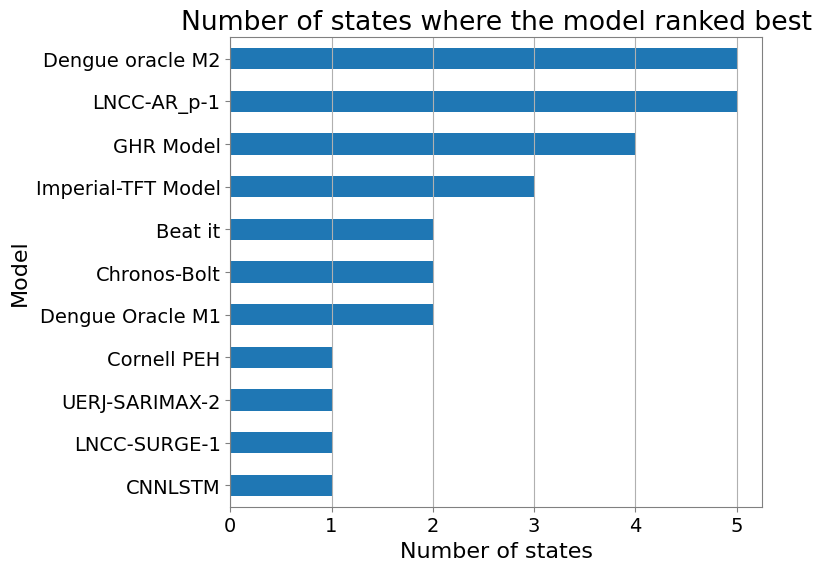

In [17]:
df_bm_st = df_bm_norm.rename(columns={'best_model_norm': 'best_model_all'})
df_bm_st['best_model_all'] = df_bm_st.best_model_all.replace(dict_models_name)
counts = df_bm_st.best_model_all.value_counts()

# Plot horizontal bar chart
counts.plot(kind="barh", figsize=(8,6))

plt.ylabel("Model")
plt.xlabel("Number of states")
plt.title("Number of states where the model ranked best")
plt.gca().invert_yaxis()  # optional: puts the highest bar at the top
plt.grid(axis='x')
plt.tight_layout()
#plt.savefig('figures/count_best_models_state.png', dpi=450, bbox_inches='tight')
plt.show()

Rank best models by season:

In [18]:
def get_rank_by_model(df_metrics, state, model, val_test = '1'):    
    df_ = df_metrics.loc[(df_metrics.validation_test == val_test) & 
                (df_metrics.state == state)].sort_values(by = 'WIS')

    df_['rank'] = np.arange(1, df_.shape[0]+1)

    return df_.loc[df_.model == dict_name_models[model]]['rank'].values[0]

In [19]:
df_rank_by_model_st = pd.DataFrame()

for st in df_metrics.state.unique(): 
    
    model = df_bm_st.loc[df_bm_st.state == st].best_model_all.values[0]

    for val in ['1', '2', '3']:

        rank = get_rank_by_model(df_metrics, st, model, val)

        df_rank_by_model_st = pd.concat([df_rank_by_model_st,
                    
                    pd.DataFrame([[model,st, val,rank]],
                                 columns = ['model', 'state', 
                                            'val_test', 'rank'])], 
                                            ignore_index = True)
        
df_rank_by_model_st['val_test'] = df_rank_by_model_st['val_test'].replace(
    {'1': 2023, '2': 2024, '3': 2025}
) 
df_rank_by_model_st

/var/folders/ch/kxpr39wx44v97968yr_4hmch0000gn/T/ipykernel_68163/3328137558.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_rank_by_model_st['val_test'] = df_rank_by_model_st['val_test'].replace(


,model,state,val_test,rank
0,Dengue oracle M2,PA,2023,5
1,Dengue oracle M2,PA,2024,7
2,Dengue oracle M2,PA,2025,1
3,Dengue Oracle M1,SP,2023,1
4,Dengue Oracle M1,SP,2024,7
...,...,...,...,...
76,Imperial-TFT Model,TO,2024,6
77,Imperial-TFT Model,TO,2025,2
78,CNNLSTM,SE,2023,1
79,CNNLSTM,SE,2024,1


In [24]:
df_pv = df_rank_by_model_st.pivot(index = 'val_test', columns = 'state', values = 'rank')

order = ['PR', 'SC', 'RS','SP', 'MG', 'RJ', 'ES', 
         'DF', 'MT', 'MS', 'GO', 'BA', 'CE', 'PE',
        'PB', 'PI', 'RN', 'MA', 'AL', 'SE',
         'RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO' ]

df_pv = df_pv[order]


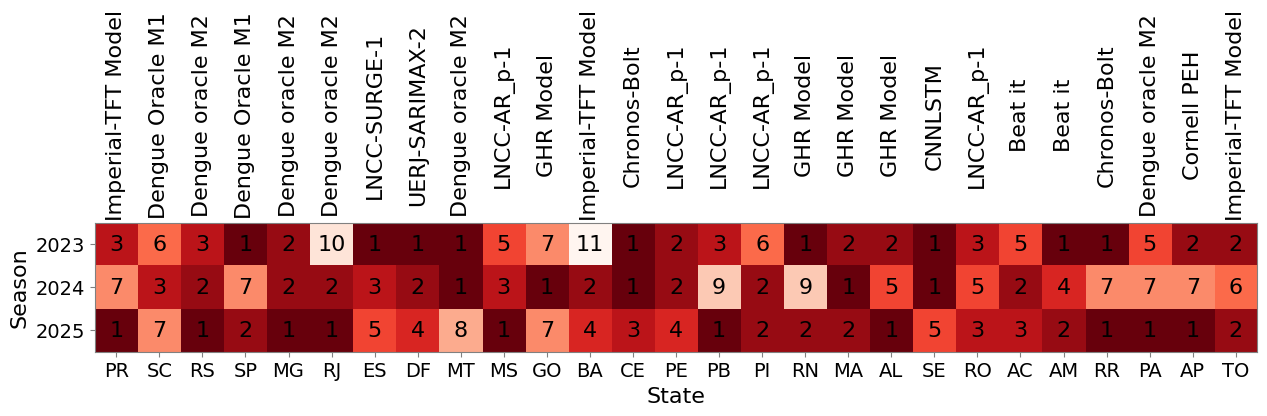

In [26]:
fig, ax = plt.subplots(figsize = (15, 3))

# Show as image
im = ax.imshow(df_pv.values, cmap="Reds_r")

# Add labels
ax.set_xticks(np.arange(df_pv.shape[1]))
ax.set_yticks(np.arange(df_pv.shape[0]))
ax.set_xticklabels(df_pv.columns)
ax.set_yticklabels(df_pv.index)

for i in range(df_pv.shape[0]):
    for j in range(df_pv.shape[1]):
        text = ax.text(j, i, df_pv.iloc[i, j],
                       ha="center", va="center", color="black")

for j in range(df_pv.shape[1]):
    
    model = df_rank_by_model_st.loc[df_rank_by_model_st.state == df_pv.columns[j]].model.values[0]

    text = ax.text(j, -3, model,
                       ha="center", va="center", color="black", 
                       rotation=90)
        
ax.set_xlabel('State')
ax.set_ylabel('Season')

plt.savefig('figures/rank_best_models_norm.png', dpi = 400, bbox_inches = 'tight')
plt.show()

In [ ]:
df_metrics.loc[(df_metrics.state == 'SC') & (df_metrics.validation_test == '3')].sort_values(by = 'WIS')

In [ ]:
df_mean_metrics.loc[df_mean_metrics.state == 'SC'].sort_values(by ='WIS')

In [ ]:
df_metrics.loc[(df_metrics.state == 'SC') & (df_metrics.model == 157)]

In [ ]:
df_bm_norm = df_mean_metrics.loc[df_mean_metrics.groupby("state")["WIS"].idxmin()][['model', 'state']].rename(columns = {'model':'best_model_norm'})
df_bm_norm.head()